# Assignment 1 – Solving XOR with a Deep Neural Network
This notebook demonstrates solving the XOR problem using a Deep Neural Network (DNN) implemented from scratch in NumPy.

Training finished at epoch: 59
Final loss: 0.6032667532286936
Input [0.0, 0.0] -> Pred: 0.3842 (thr-> 0), Expected: 0
Input [0.0, 1.0] -> Pred: 0.5565 (thr-> 1), Expected: 1
Input [1.0, 0.0] -> Pred: 0.5025 (thr-> 1), Expected: 1
Input [1.0, 1.0] -> Pred: 0.4767 (thr-> 0), Expected: 0


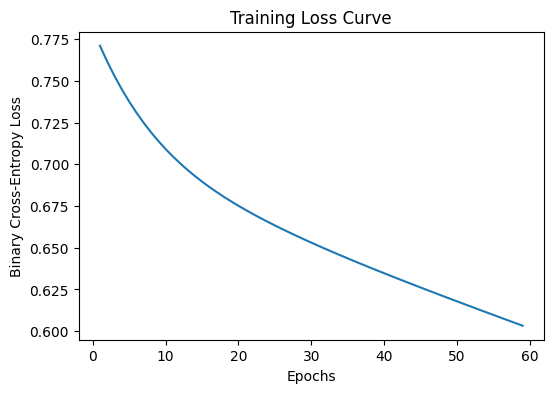

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# XOR data
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Y = np.array([[0],[1],[1],[0]], dtype=float)

np.random.seed(42)
n_samples, n_features = X.shape
hidden_units = 4

limit1 = np.sqrt(6 / (n_features + hidden_units))
W1 = np.random.uniform(-limit1, limit1, size=(n_features, hidden_units))
b1 = np.zeros((1, hidden_units))

limit2 = np.sqrt(6 / (hidden_units + 1))
W2 = np.random.uniform(-limit2, limit2, size=(hidden_units, 1))
b2 = np.zeros((1, 1))

lr = 0.1
max_epochs = 20000
loss_history = []

for epoch in range(1, max_epochs + 1):
    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    Yhat = sigmoid(Z2)

    loss = bce_loss(Y, Yhat)
    loss_history.append(loss)

    dZ2 = (Yhat - Y) / n_samples
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (1 - A1**2)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    preds = (Yhat >= 0.5).astype(int)
    if np.array_equal(preds, Y.astype(int)):
        break

print('Training finished at epoch:', len(loss_history))
print('Final loss:', loss_history[-1])

# Final predictions
Z1 = X @ W1 + b1
A1 = np.tanh(Z1)
Z2 = A1 @ W2 + b2
Yhat = sigmoid(Z2)
preds = (Yhat >= 0.5).astype(int)
for i in range(len(X)):
    print(f'Input {X[i].tolist()} -> Pred: {float(Yhat[i,0]):.4f} (thr-> {int(preds[i,0])}), Expected: {int(Y[i,0])}')

# Plot loss
plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.show()